# Zero Shot Unroll On Regular Mesh

Notebook minimal pour tester un checkpoint existant en zero-shot sur le dataset regulier projete.

Flux :
- charger le maillage regulier
- charger `*_base.bin` et `*.pkl` avec `split="test"`
- reutiliser les stats du checkpoint via `ckpt_path`
- faire un unrolling auto-regressif simple sur une sequence
- afficher `h initial`, `h gt`, `h pred` et `|error h|`


In [1]:
import glob
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import numpy as np
import torch


def find_project_root(start: Path) -> Path:
    for path in [start.resolve(), *start.resolve().parents]:
        if (path / "python" / "create_dgl_dataset.py").exists():
            return path
    raise RuntimeError("Cannot find gnn_modulus_test project root.")


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from python.create_dgl_dataset import TelemacDataset, TelemacDatasetWithQ, add_mesh_info
from python.eval_rollout import build_model, build_rollout_context, create_rollout_state, denormalize_state, load_model_checkpoint, rollout_step
from python.python_code.data_manip.extraction.telemac_file import TelemacFile

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cuda


In [2]:
MODEL_CONFIG = {
    "name": "paper_checkpoint",
    "ckpt_dir": "/work/m24046/m24046mrcr/paper/Experience10/Seed0/",
    "epoch": 900,
    "use_q_feature": True,
    "mesh": "full_flood",
    "num_input_features": 10,
    "num_output_features": 3,
    "num_edge_features": 3,
    "mp_layers": 10,
    "do_concat_trick": True,
    "num_processor_checkpoint_segments": 0,
    "dt_seconds": 1800.0,
}

    
REGULAR_MESH_SLF = "/work/m24046/m24046mrcr/Test_Tet_regular/Tet_regular_50m.slf"
REGULAR_BASE_BIN = "/work/m24046/m24046mrcr/Test_Tet_regular/dataset_50m/regular_50_dataset_base.bin"

dynamic_files = ["/work/m24046/m24046mrcr/Test_Tet_regular/dataset_50m_short/regular_50_dataset_G1_P2600_0_35-64.pkl",
                "/work/m24046/m24046mrcr/Test_Tet_regular/dataset_50m_short/regular_50_dataset_G2_P1000_0_35-64.pkl",
                "/work/m24046/m24046mrcr/Test_Tet_regular/dataset_50m_short/regular_50_dataset_G2_P1200_0_35-64.pkl",
                "/work/m24046/m24046mrcr/Test_Tet_regular/dataset_50m_short/regular_50_dataset_G2_P1600_0_35-64.pkl",
                "/work/m24046/m24046mrcr/Test_Tet_regular/dataset_50m_short/regular_50_dataset_G4_P2000_0_35-64.pkl",
                "/work/m24046/m24046mrcr/Test_Tet_regular/dataset_50m_short/regular_50_dataset_G1_P1200_0_35-64.pkl",
                "/work/m24046/m24046mrcr/Test_Tet_regular/dataset_50m_short/regular_50_dataset_G1_P2400_0_35-64.pkl",
                "/work/m24046/m24046mrcr/Test_Tet_regular/dataset_50m_short/regular_50_dataset_G3_P3400_0_35-64.pkl",
                ]



# A remplir seulement si le modele utilise Q.
REGULAR_HYDRO_FILES = ["/work/m24046/m24046mrcr/dataset_x8_avec_ts/hydrogrammes/generated_hydrographs_Group_1_peak_2600.liq",
                      "/work/m24046/m24046mrcr/dataset_x8_avec_ts/hydrogrammes/generated_hydrographs_Group_2_peak_1000.liq",
                      "/work/m24046/m24046mrcr/dataset_x8_avec_ts/hydrogrammes/generated_hydrographs_Group_2_peak_1200.liq",
                      "/work/m24046/m24046mrcr/dataset_x8_avec_ts/hydrogrammes/generated_hydrographs_Group_2_peak_1600.liq",
                      "/work/m24046/m24046mrcr/dataset_x8_avec_ts/hydrogrammes/generated_hydrographs_Group_4_peak_2000.liq",
                      "/work/m24046/m24046mrcr/dataset_x8_avec_ts/hydrogrammes/generated_hydrographs_Group_1_peak_1200.liq",
                      "/work/m24046/m24046mrcr/dataset_x8_avec_ts/hydrogrammes/generated_hydrographs_Group_1_peak_2400.liq",
                      "/work/m24046/m24046mrcr/dataset_x8_avec_ts/hydrogrammes/generated_hydrographs_Group_3_peak_3400.liq",
                      ]

MAX_DYNAMIC_FILES = 1
UNROLL_STEPS = 12
OVERLAP = UNROLL_STEPS
SEQUENCE_INDEX = 0
PLOT_STEP = 12
STEP_HOURS = MODEL_CONFIG["dt_seconds"] / 3600.0
FIGSIZE = (16, 4)


In [3]:
def require_existing(path_like, label):
    path = Path(path_like).expanduser()
    if not path.exists():
        raise FileNotFoundError(f"{label} introuvable: {path}")
    return path


def build_dataset(sequence_length, overlap):
    base_kwargs = {
        "data_dir": str(regular_base_path),
        "dynamic_data_files": [str(path) for path in dynamic_files],
        "split": "test",
        "ckpt_path": str(ckpt_dir),
        "normalize": True,
        "sequence_length": sequence_length,
        "overlap": overlap,
    }

    if MODEL_CONFIG["use_q_feature"]:
        return TelemacDatasetWithQ(
            name="regular_unroll_q",
            hydro_data_files=[str(path) for path in hydro_files],
            dt_seconds=MODEL_CONFIG["dt_seconds"],
            **base_kwargs,
        )

    return TelemacDataset(name="regular_unroll", **base_kwargs)


regular_mesh_path = require_existing(REGULAR_MESH_SLF, "REGULAR_MESH_SLF")
regular_base_path = require_existing(REGULAR_BASE_BIN, "REGULAR_BASE_BIN")
ckpt_dir = require_existing(MODEL_CONFIG["ckpt_dir"], "CKPT_DIR")



hydro_files = []
if MODEL_CONFIG["use_q_feature"]:
    if REGULAR_HYDRO_FILES:
        hydro_files = [require_existing(path, f"HYDRO_FILE[{i}]") for i, path in enumerate(REGULAR_HYDRO_FILES)]
    elif REGULAR_HYDRO_FILE:
        hydro_path = require_existing(REGULAR_HYDRO_FILE, "REGULAR_HYDRO_FILE")
        hydro_files = [hydro_path for _ in dynamic_files]
    else:
        raise ValueError("Ce modele utilise Q. Renseigne REGULAR_HYDRO_FILE ou REGULAR_HYDRO_FILES.")

    if len(hydro_files) != len(dynamic_files):
        raise ValueError(
            f"Nombre de hydro_files ({len(hydro_files)}) different du nombre de dynamic_files ({len(dynamic_files)})."
        )

print("model:", MODEL_CONFIG["name"])
print("ckpt dir:", ckpt_dir)
print("normalization:", 'split="test" + ckpt_path=checkpoint')
print("use_q_feature:", MODEL_CONFIG["use_q_feature"])
print("regular mesh:", regular_mesh_path)
print("regular base:", regular_base_path)
print("dynamic files:")
for path in dynamic_files:
    print(" -", path)
if hydro_files:
    print("hydro files:")
    for path in hydro_files:
        print(" -", path)


model: paper_checkpoint
ckpt dir: /work/m24046/m24046mrcr/paper/Experience10/Seed0
normalization: split="test" + ckpt_path=checkpoint
use_q_feature: True
regular mesh: /work/m24046/m24046mrcr/Test_Tet_regular/Tet_regular_50m.slf
regular base: /work/m24046/m24046mrcr/Test_Tet_regular/dataset_50m/regular_50_dataset_base.bin
dynamic files:
 - /work/m24046/m24046mrcr/Test_Tet_regular/dataset_50m_short/regular_50_dataset_G1_P2600_0_35-64.pkl
 - /work/m24046/m24046mrcr/Test_Tet_regular/dataset_50m_short/regular_50_dataset_G2_P1000_0_35-64.pkl
 - /work/m24046/m24046mrcr/Test_Tet_regular/dataset_50m_short/regular_50_dataset_G2_P1200_0_35-64.pkl
 - /work/m24046/m24046mrcr/Test_Tet_regular/dataset_50m_short/regular_50_dataset_G2_P1600_0_35-64.pkl
 - /work/m24046/m24046mrcr/Test_Tet_regular/dataset_50m_short/regular_50_dataset_G4_P2000_0_35-64.pkl
 - /work/m24046/m24046mrcr/Test_Tet_regular/dataset_50m_short/regular_50_dataset_G1_P1200_0_35-64.pkl
 - /work/m24046/m24046mrcr/Test_Tet_regular/datas

In [4]:
mesh = TelemacFile(str(regular_mesh_path))
xy, triangles = add_mesh_info(mesh)
triangulation = mtri.Triangulation(xy[:, 0], xy[:, 1], triangles)

dataset = build_dataset(sequence_length=UNROLL_STEPS + 1, overlap=OVERLAP)
expected_input_features = dataset.base_graph.ndata["static"].shape[1] + (4 if MODEL_CONFIG["use_q_feature"] else 3)
if MODEL_CONFIG["num_input_features"] != expected_input_features:
    raise ValueError(
        f"num_input_features={MODEL_CONFIG['num_input_features']} incompatible avec le dataset ({expected_input_features})."
    )

model = build_model(
    num_input_features=MODEL_CONFIG["num_input_features"],
    num_edge_features=MODEL_CONFIG["num_edge_features"],
    num_output_features=MODEL_CONFIG["num_output_features"],
    mp_layers=MODEL_CONFIG["mp_layers"],
    do_concat_trick=MODEL_CONFIG["do_concat_trick"],
    num_processor_checkpoint_segments=MODEL_CONFIG["num_processor_checkpoint_segments"],
)
model = load_model_checkpoint(model, str(ckpt_dir), MODEL_CONFIG["epoch"], device)
context = build_rollout_context(dataset, device, MODEL_CONFIG["use_q_feature"])

print("mesh nodes:", len(xy))
print("mesh triangles:", len(triangles))
print("dataset sequences:", len(dataset))
print("expected input features:", expected_input_features)
print("loaded checkpoint epoch:", MODEL_CONFIG["epoch"])


Loading normalization statistics...


[13:08:13 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/paper/Experience10/Seed0/MeshGraphNet.0.900.mdlus to device cuda
[13:08:13 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/paper/Experience10/Seed0/checkpoint.0.900.pt to device cuda


mesh nodes: 69004
mesh triangles: 136704
dataset sequences: 144
expected input features: 10
loaded checkpoint epoch: 900


In [5]:
def unroll_one_sequence(ds, model, context, sequence_index, unroll_steps):
    graphs = ds[sequence_index]
    if len(graphs) < 2:
        raise ValueError("La sequence choisie ne contient pas assez de pas de temps.")

    state = create_rollout_state(graphs[0], context)
    initial = denormalize_state(state.xn_t_full[:, :3], context).detach().cpu().numpy()

    pred_steps = []
    gt_steps = []
    rows = []

    max_steps = min(unroll_steps, len(graphs) - 1)
    for step in range(1, max_steps + 1):
        x_gt_full_n = graphs[step].ndata["x"][:, context.dyn_start:context.dyn_start + context.dyn_len].to(context.device)
        x_gt = denormalize_state(x_gt_full_n[:, :3], context)
        q_t1_n = x_gt_full_n[:, 3:4] if context.dyn_len == 4 else None

        result = rollout_step(
            model=model,
            state=state,
            context=context,
            x_gt=x_gt,
            q_t1_n=q_t1_n,
        )

        pred_np = result.predicted_state.detach().cpu().numpy()
        gt_np = result.target_state.detach().cpu().numpy()
        pred_steps.append(pred_np)
        gt_steps.append(gt_np)
        rows.append(
            {
                "step": step,
                "hours": step * STEP_HOURS,
                "mse_h": float(np.mean((pred_np[:, 0] - gt_np[:, 0]) ** 2)),
            }
        )

        state = result.next_state

    return initial, pred_steps, gt_steps, rows


initial, pred_steps, gt_steps, rows = unroll_one_sequence(
    ds=dataset,
    model=model,
    context=context,
    sequence_index=SEQUENCE_INDEX,
    unroll_steps=UNROLL_STEPS,
)

for row in rows:
    print(row)


{'step': 1, 'hours': 0.5, 'mse_h': 0.001632742932997644}
{'step': 2, 'hours': 1.0, 'mse_h': 0.006905383430421352}
{'step': 3, 'hours': 1.5, 'mse_h': 0.017784258350729942}
{'step': 4, 'hours': 2.0, 'mse_h': 0.03597358241677284}
{'step': 5, 'hours': 2.5, 'mse_h': 0.06224413961172104}
{'step': 6, 'hours': 3.0, 'mse_h': 0.09966873377561569}
{'step': 7, 'hours': 3.5, 'mse_h': 0.15305179357528687}
{'step': 8, 'hours': 4.0, 'mse_h': 0.22482804954051971}
{'step': 9, 'hours': 4.5, 'mse_h': 0.31890255212783813}
{'step': 10, 'hours': 5.0, 'mse_h': 0.4434840679168701}
{'step': 11, 'hours': 5.5, 'mse_h': 0.597926676273346}
{'step': 12, 'hours': 6.0, 'mse_h': 0.7918924689292908}


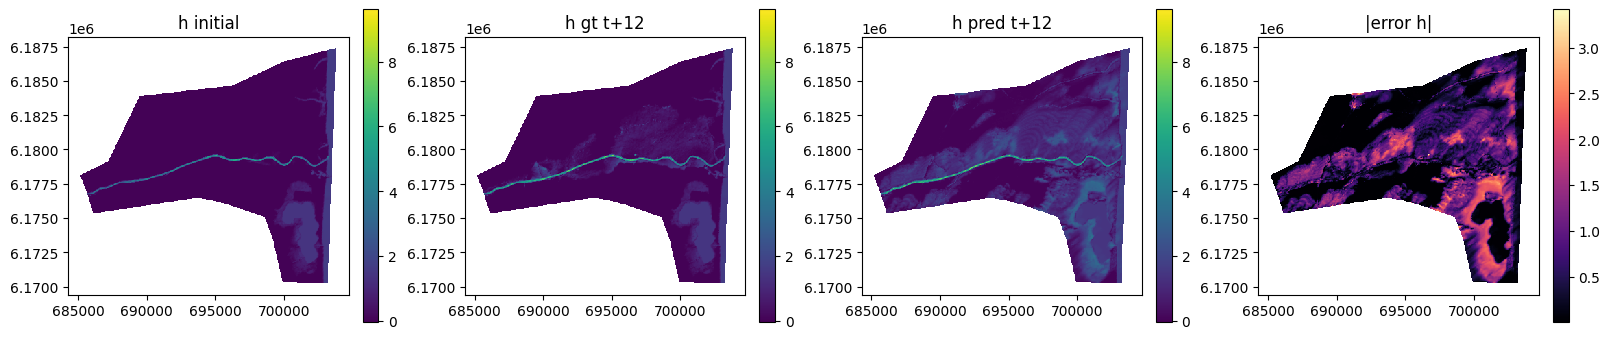

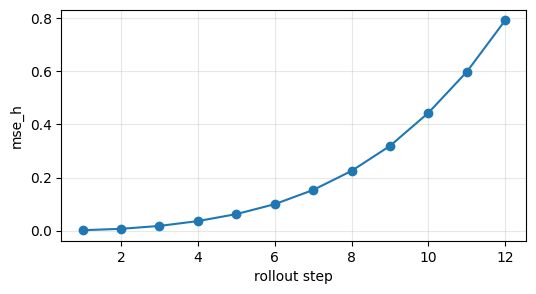

sequence index: 0
plot step: 12 (6.0 h)
mse_h: 0.7918924689292908


In [6]:
if not pred_steps:
    raise ValueError("Aucun pas d'unrolling disponible.")

plot_step = min(PLOT_STEP, len(pred_steps))
pred = pred_steps[plot_step - 1]
gt = gt_steps[plot_step - 1]
row = rows[plot_step - 1]

initial_h = initial[:, 0]
pred_h = pred[:, 0]
gt_h = gt[:, 0]

h_vmin = float(min(initial_h.min(), gt_h.min(), pred_h.min()))
h_vmax = float(max(initial_h.max(), gt_h.max(), pred_h.max()))

fig, axes = plt.subplots(1, 4, figsize=FIGSIZE, constrained_layout=True)

plots = [
    ("h initial", initial_h, "viridis", h_vmin, h_vmax),
    (f"h gt t+{plot_step}", gt_h, "viridis", h_vmin, h_vmax),
    (f"h pred t+{plot_step}", pred_h, "viridis", h_vmin, h_vmax),
    ("|error h|", np.abs(pred_h - gt_h), "magma", None, None),
]

for ax, (title, values, cmap, vmin, vmax) in zip(axes, plots):
    artist = ax.tripcolor(triangulation, values, shading="flat", cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_aspect("equal")
    fig.colorbar(artist, ax=ax, shrink=0.8)

plt.show()

steps = [item["step"] for item in rows]
mse_h = [item["mse_h"] for item in rows]

plt.figure(figsize=(6, 3))
plt.plot(steps, mse_h, marker="o")
plt.xlabel("rollout step")
plt.ylabel("mse_h")
plt.grid(True, alpha=0.3)
plt.show()

print("sequence index:", SEQUENCE_INDEX)
print(f"plot step: {plot_step} ({STEP_HOURS * plot_step:.1f} h)")
print("mse_h:", row["mse_h"])
